In [21]:
# Load data
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.read_csv("D:/Goutham/Projects/Python/Project 3/Multi Linear Regression - Assignment -3_4/3. Multi Linear Regression/50_Startups.csv")
df.head()

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94


In [20]:
# Understand data
df.shape
df.info()
df.describe()
df.columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   Profit           50 non-null     float64
 4   State_Florida    50 non-null     bool   
 5   State_New York   50 non-null     bool   
dtypes: bool(2), float64(4)
memory usage: 1.8 KB


Index(['R&D Spend', 'Administration', 'Marketing Spend', 'Profit',
       'State_Florida', 'State_New York'],
      dtype='object')

In [32]:
# handle categorical values
df = pd.get_dummies(df, drop_first=True)
df.head()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


In [18]:
# correlation
df.corr()

,R&D Spend,Administration,Marketing Spend,Profit,State_Florida,State_New York
R&D Spend,1.000000,0.241955,0.724248,0.972900,0.105711,0.039068
Administration,0.241955,1.000000,-0.032154,0.200717,0.010493,0.005145
Marketing Spend,0.724248,-0.032154,1.000000,0.747766,0.205685,-0.033670
Profit,0.972900,0.200717,0.747766,1.000000,0.116244,0.031368
State_Florida,0.105711,0.010493,0.205685,0.116244,1.000000,-0.492366
State_New York,0.039068,0.005145,-0.033670,0.031368,-0.492366,1.000000


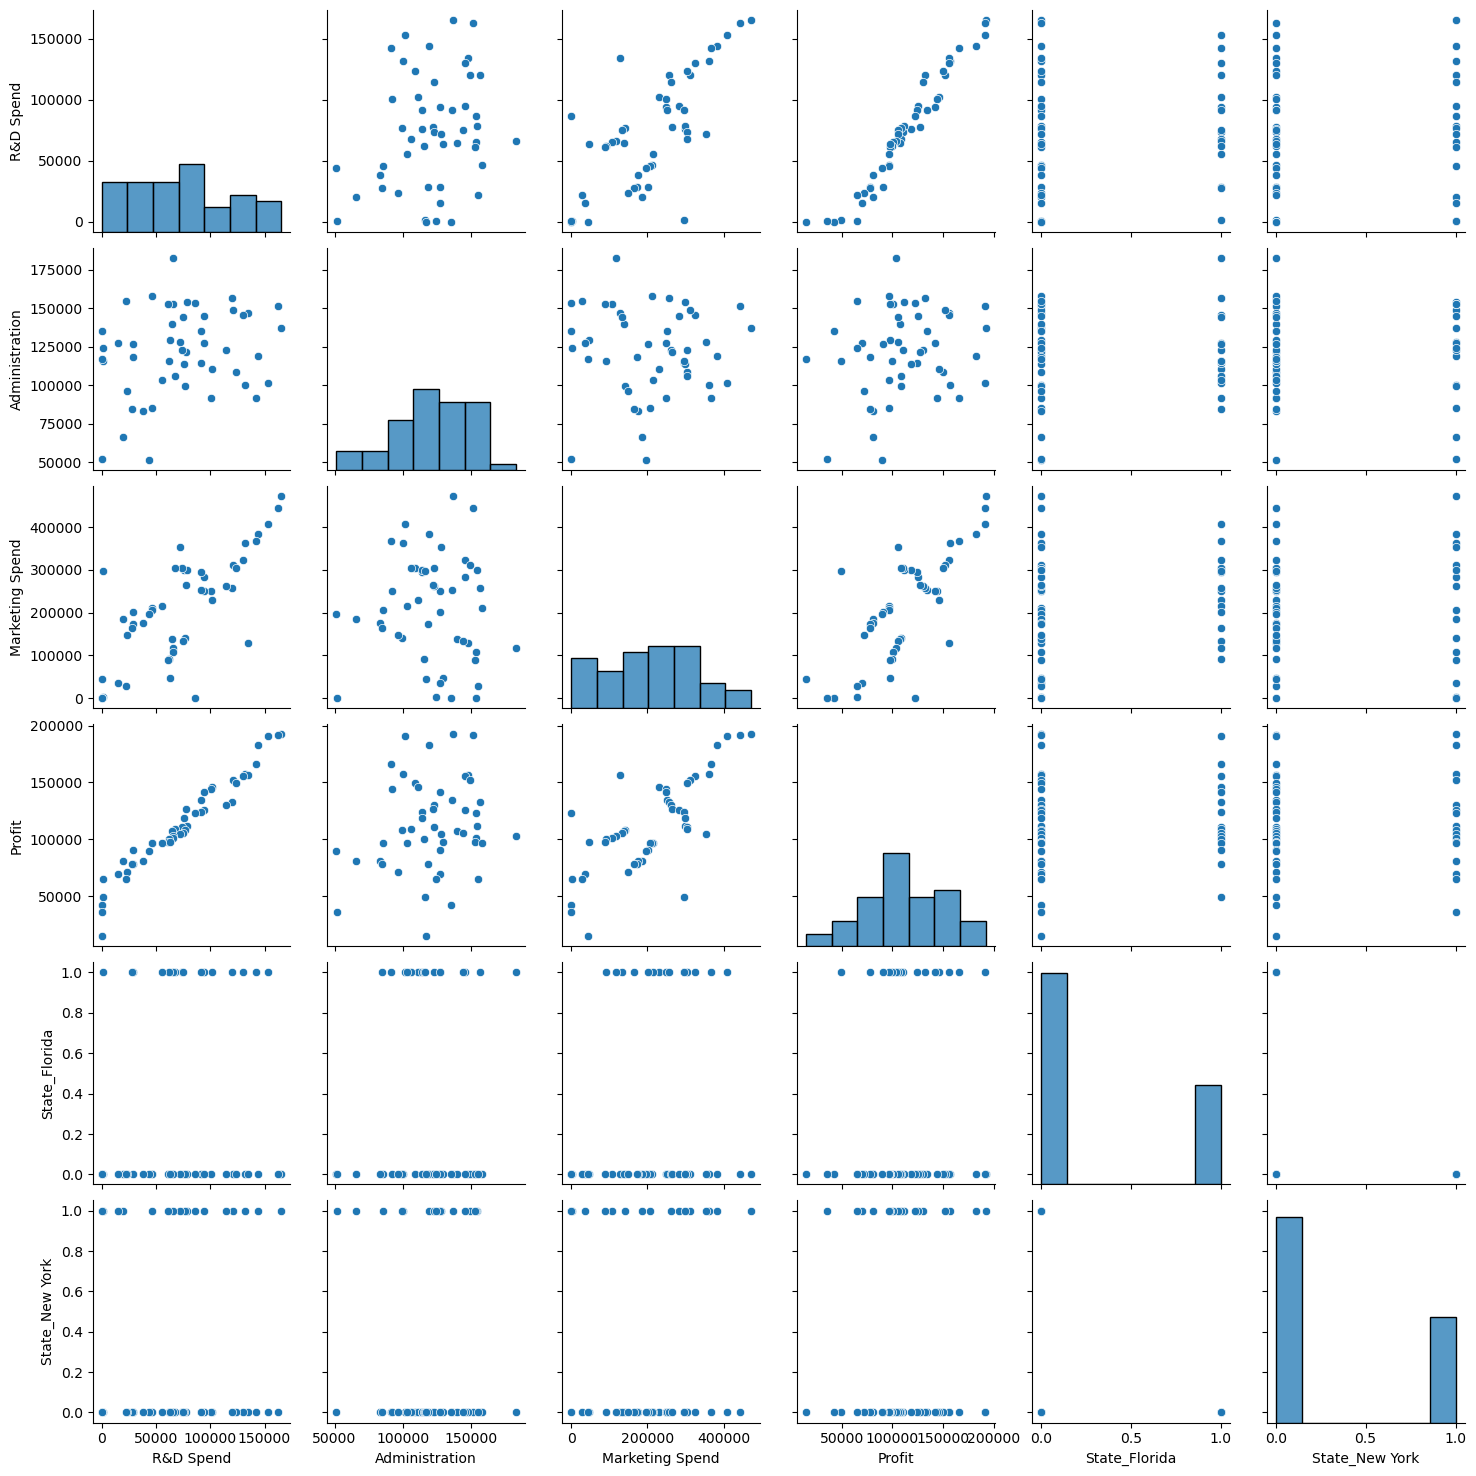

In [17]:
# visualization
sns.pairplot(df)
plt.show()

In [16]:
# Define X, y
X = df.drop('Profit', axis=1)
y = df['Profit']

In [15]:
# build model
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X, y)

LinearRegression()

In [14]:
# Predict
y_pred = model.predict(X)

In [13]:
# Evaluate

from sklearn.metrics import r2_score

r2 = r2_score(y, y_pred)
r2

0.9507524843355148

In [22]:
# Transformations

In [24]:
# Log(X) Transformation
import numpy as np

X_log = np.log(X + 1)  # +1 to avoid log(0)

model_log = LinearRegression().fit(X_log, y)
y_pred_log = model_log.predict(X_log)

r2_log = r2_score(y, y_pred_log)
r2_log

0.5370248112902614

In [25]:
# log(y) Transformation
y_log = np.log(y)

model_exp = LinearRegression().fit(X, y_log)
y_pred_exp = np.exp(model_exp.predict(X))

r2_exp = r2_score(y, y_pred_exp)
r2_exp

0.8538321824320546

In [26]:
# Compare models
results = pd.DataFrame({
    'Model': ['Linear', 'Log_X', 'Log_Y'],
    'R2': [r2, r2_log, r2_exp]
})

results

,Model,R2
0,Linear,0.950752
1,Log_X,0.537025
2,Log_Y,0.853832


In [27]:
# Choosing the best model

In [28]:
# Predict new values
new_data = X.head(3)
model.predict(new_data)

array([192390.57136321, 189071.32010494, 182276.18673283])

In [29]:
# saving output
output = pd.DataFrame({
    'Actual': y.head(3),
    'Predicted': model.predict(new_data)
})

output.to_csv("D:/Goutham/Projects/Python/Project 3/Multi Linear Regression - Assignment -3_4/3. Multi Linear Regression/startup_predictions.csv", index=False)

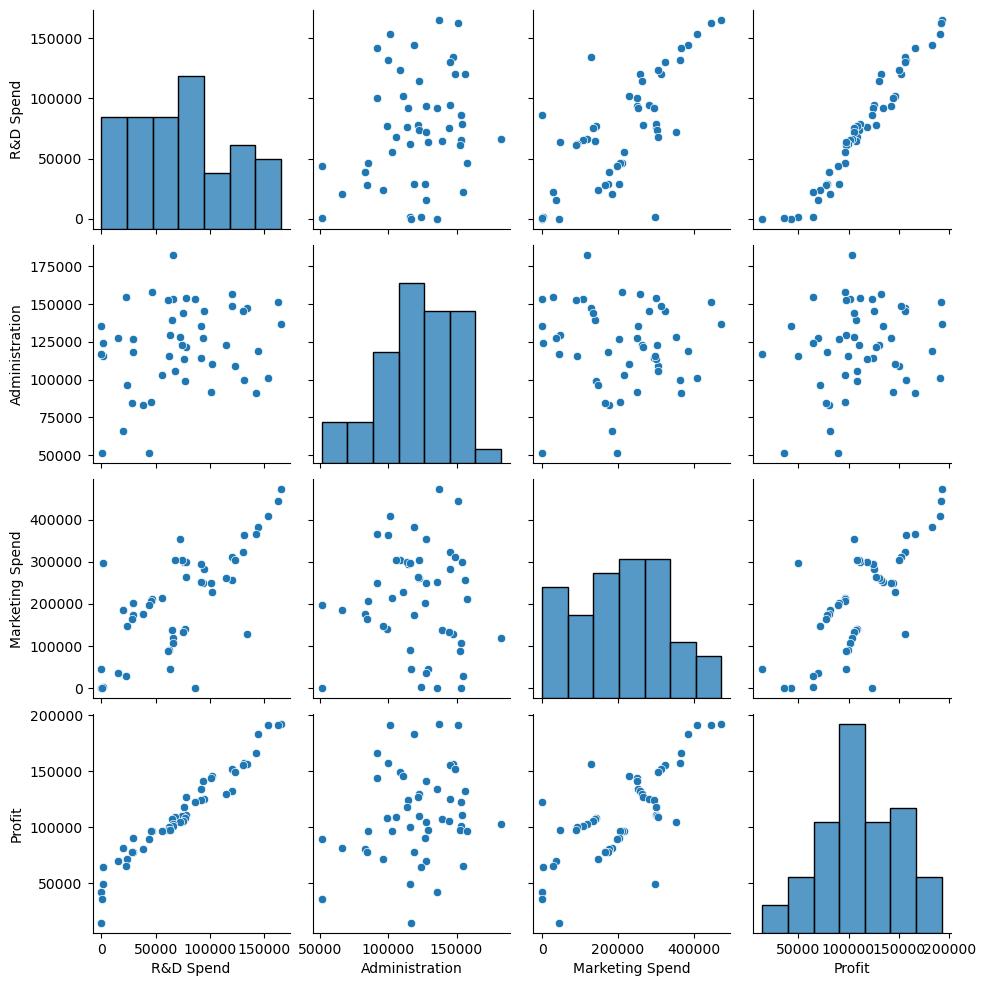

In [30]:
# pairplot
sns.pairplot(df)

<Axes: >

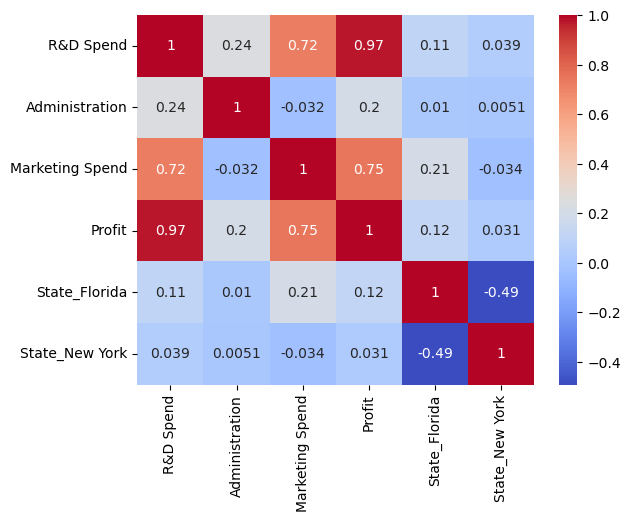

In [33]:
# Heatmap
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')